# 8. Validation Design and Launch Readiness

Notebook 8 converts the accumulated evidence into an operational validation plan. By this point the priority policy has passed Season 2 replay screening, replay guardrails, OPE diagnostics, heterogeneity checks, robustness stress tests, and Season 3 out-of-time validation. The remaining question is not which policy looks best offline. The remaining question is what evidence is still missing before launch.

This notebook builds the validation-design artifacts, launch-readiness checklist, final recommendation, and validation sequence used by the paper. It intentionally keeps the recommendation conservative: validate online before launch.



## What This Notebook Creates

Inputs from previous notebooks:

- `metadata/reserve_policy_candidate_handoff.csv`
- `metadata/marketplace_scorecard.csv`
- `metadata/theory_guided_sensitivity_verdict.csv`
- `metadata/season3_priority_policy_validation.csv`

Generated analysis artifacts:

- `metadata/policy_validation_plan.csv`
- `metadata/shadow_logging_plan.csv`
- `metadata/validation_design_detectability.csv`
- `metadata/experiment_design_recommendations.csv`
- `metadata/final_policy_recommendation.csv`
- `metadata/launch_readiness_checklist.csv`
- `metadata/final_validation_sequence.csv`

Generated figures:

- `artifacts/figures/11_validation_design_and_launch_readiness.png`
- `artifacts/figures/11_decision_waterfall_and_validation_sequence.png`

The notebook may also refresh decision-rule ablation inputs because the current `DecisionEngine` writes the final recommendation and ablation artifacts together. The ablation figures are reserved for the next notebook.



## Reproducibility Setup

The calculations in this notebook are deterministic transformations of existing replay, OPE, robustness, and Season 3 validation artifacts. No raw panel is read and no model is refit here.



In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/ and pyproject.toml")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")



Repository root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code


In [2]:
from IPython.display import Image, display

from checks import ArtifactRepository
from config import PaperConfig, ProjectPaths, RawPipelineConfig
from data_access import Workspace
from decision_engine import DecisionEngine
from figures import FigureRenderer
from ope import OPEEvidenceBuilder
from policy_catalog import ReservePolicyCatalog
from progress import ProgressLogger



In [3]:
SOURCE_ROOT = REPO_ROOT / "artifacts" / "workspace"
OUTPUT_ROOT = REPO_ROOT / "artifacts"
RUN_VALIDATION_DESIGN = True
RUN_FINAL_DECISION = True

paths = ProjectPaths.from_cli(SOURCE_ROOT, OUTPUT_ROOT)
paths.ensure_output_dirs()
repository = ArtifactRepository(paths)
repository.require_layout()
workspace = Workspace(paths.source_root)
progress = ProgressLogger(enabled=True)
config = RawPipelineConfig(
    data_root=REPO_ROOT / "data",
    workspace_root=SOURCE_ROOT,
    full_run=True,
    clean_workspace=False,
)
paper_config = PaperConfig()

required = [
    paths.metadata_dir / "reserve_policy_price_landscape.csv",
    paths.metadata_dir / "reserve_policy_candidate_handoff.csv",
    paths.metadata_dir / "marketplace_scorecard.csv",
    paths.metadata_dir / "theory_guided_sensitivity_verdict.csv",
    paths.metadata_dir / "season3_priority_policy_validation.csv",
]
missing = [path.relative_to(REPO_ROOT) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run notebooks 3, 4, 6, and 7 before launch-readiness analysis. "
        f"Missing: {missing}"
    )

print("Required decision artifacts are present.")



Required decision artifacts are present.


## Frozen Catalog and Evidence Snapshot

The final recommendation uses the same policy catalog and priority policy used throughout the paper. The snapshot below records the key evidence entering the launch-readiness decision: Season 2 replay lift, conservative OPE lower-tail lift, response-loss break-even point, and Season 3 holdout lift.



In [4]:
price_landscape = repository.read_csv("reserve_policy_price_landscape.csv")
price_values = price_landscape.set_index("stat")["value"].to_dict()
price_quantiles = {
    "q25": float(price_values["positive_floor_q25"]),
    "q50": float(price_values["positive_floor_q50"]),
    "q75": float(price_values["positive_floor_q75"]),
}
catalog = ReservePolicyCatalog(price_quantiles)

scorecard = repository.read_csv("marketplace_scorecard.csv")
robustness = repository.read_csv("theory_guided_sensitivity_verdict.csv")
season3 = repository.read_csv("season3_priority_policy_validation.csv")

snapshot = scorecard.head(1)[[
    "policy_id",
    "pct_delta_yield_per_opportunity_vs_baseline",
    "crossfit_dr_pct_lift_p10",
    "weighted_evidence_score",
]].merge(
    robustness[["policy_id", "break_even_market_response_loss_share"]],
    on="policy_id",
    how="left",
).merge(
    season3[["policy_id", "season3_pct_yield_lift", "season3_rank"]],
    on="policy_id",
    how="left",
)
snapshot



,policy_id,pct_delta_yield_per_opportunity_vs_baseline,crossfit_dr_pct_lift_p10,weighted_evidence_score,break_even_market_response_loss_share,season3_pct_yield_lift,season3_rank
0,hybrid_q75_if_gap_100,0.476604,0.458253,4.305,0.32277,0.438722,1


## Build Validation-Design and Final-Decision Artifacts

`OPEEvidenceBuilder.build_experiment_design()` creates the validation-plan and MDE artifacts from the replay handoff and scorecard. `DecisionEngine.build_final_decision_and_ablation()` creates the final recommendation, launch-readiness checklist, and validation sequence. The ablation artifacts written by the decision engine are intentionally not interpreted here; they are for the next notebook.



In [5]:
if RUN_VALIDATION_DESIGN:
    OPEEvidenceBuilder(workspace, config, catalog, progress=progress).build_experiment_design()

if RUN_FINAL_DECISION:
    DecisionEngine(workspace, config, catalog, progress=progress).build_final_decision_and_ablation()

validation_plan = repository.read_csv("policy_validation_plan.csv")
shadow_plan = repository.read_csv("shadow_logging_plan.csv")
mde = repository.read_csv("validation_design_detectability.csv")
recommendation = repository.read_csv("final_policy_recommendation.csv")
checklist = repository.read_csv("launch_readiness_checklist.csv")
sequence = repository.read_csv("final_validation_sequence.csv")

print(f"Validation-plan candidate rows: {len(validation_plan):,}")
print(f"MDE design rows: {len(mde):,}")
recommendation



[     0.0s] Starting: experiment-design and validation-plan artifacts
[     0.1s] Finished: experiment-design artifacts; 16 candidate validation row(s)
[     0.1s] Starting: final decision and ablation artifacts
[     0.1s] Finished: final decision and ablation artifacts; wrote 6 rule comparisons
Validation-plan candidate rows: 16
MDE design rows: 20


,policy_id,policy_family,recommended_action,final_decision,direct_launch_ready,why_not_direct_launch,replay_yield_lift,p10_crossfit_dr_lift,weighted_evidence_score,break_even_market_response_loss_share,readiness_gates_ready,readiness_gates_validation_ready,readiness_gates_blocked,primary_validation_design,minimum_shadow_logging_duration,minimum_online_test_duration,decision_owner_summary
0,hybrid_q75_if_gap_100,hybrid_minimum_margin,"Start shadow logging, then run an exchange-hou...",shadow_log_then_exchange_hour_switchback,False,missing real known propensities and unvalidate...,0.476604,0.458253,4.305,0.32277,3,1,1,exchange_hour_switchback,7 to 14 days,14 days,Promising reserve/floor policy; validate marke...


## Validation Plan, Detectability, and Launch Readiness

The validation plan starts with shadow logging because offline replay and OPE do not observe live assignment probabilities or live bidder response. Shadow logging records candidate floors and whether each auction would have cleared under the candidate policy without changing marketplace behavior. After that instrumentation stage, the recommended online design is an exchange-hour switchback.

The MDE curves are not a full power analysis for a final production experiment. They are a planning diagnostic: they compare how detectable the current offline effect sizes would be under plausible validation durations and design classes. The paired launch-readiness panel separates evidence that is already ready from evidence that still requires online validation.



In [6]:
validation_plan[[
    "policy_id",
    "replay_yield_lift",
    "retained_impression_share",
    "value_proxy_retention",
    "validation_tier",
    "recommended_validation_design",
    "rationale",
]].head(10)



,policy_id,replay_yield_lift,retained_impression_share,value_proxy_retention,validation_tier,recommended_validation_design,rationale
0,hybrid_q75_if_gap_100,0.476604,1.000000,1.000000,high_gain_high_scrutiny,shadow_logging_then_exchange_hour_switchback,validate marketplace response before launch
1,min_positive_floor_q75,0.355075,1.000000,1.000000,high_gain_high_scrutiny,shadow_logging_then_exchange_hour_switchback,validate marketplace response before launch
2,zero_and_low_floor_to_q50,0.101179,1.000000,1.000000,moderate_gain_validate_online,shadow_logging_then_switchback_or_exchange_reg...,validate marketplace response before launch
3,hybrid_q50_if_gap_50,0.101179,1.000000,1.000000,moderate_gain_validate_online,shadow_logging_then_switchback_or_exchange_reg...,validate marketplace response before launch
4,margin_gap_100_add_20,0.097883,1.000000,1.000000,moderate_gain_validate_online,shadow_logging_then_switchback_or_exchange_reg...,validate marketplace response before launch
5,add_20_all_floors,0.097433,0.999706,0.999921,moderate_gain_validate_online,shadow_logging_then_switchback_or_exchange_reg...,validate marketplace response before launch
6,min_positive_floor_q50,0.072978,1.000000,1.000000,small_gain_low_priority,shadow_logging_or_hold_for_later,validate marketplace response before launch
7,uniform_raise_30pct,0.069190,0.997866,0.998022,small_gain_low_priority,shadow_logging_or_hold_for_later,validate marketplace response before launch
8,uniform_raise_20pct,0.044008,0.999159,0.998655,small_gain_low_priority,shadow_logging_or_hold_for_later,validate marketplace response before launch
9,margin_gap_50_add_10,0.040727,1.000000,1.000000,small_gain_low_priority,shadow_logging_or_hold_for_later,validate marketplace response before launch


In [7]:
shadow_plan



,phase,duration_recommendation,required_fields,why_needed
0,instrument_candidate_floor_decisions,7 to 14 days before any serving change,"bid_id, current_floor, candidate_floor, bid_pr...",measure support without changing marketplace b...
1,log_policy_assignment_probabilities,same as shadow period,eligible_policy_set and assignment probability,off-policy estimators require known propensities


Wrote validation-design and launch-readiness figure to artifacts/figures/11_validation_design_and_launch_readiness.png


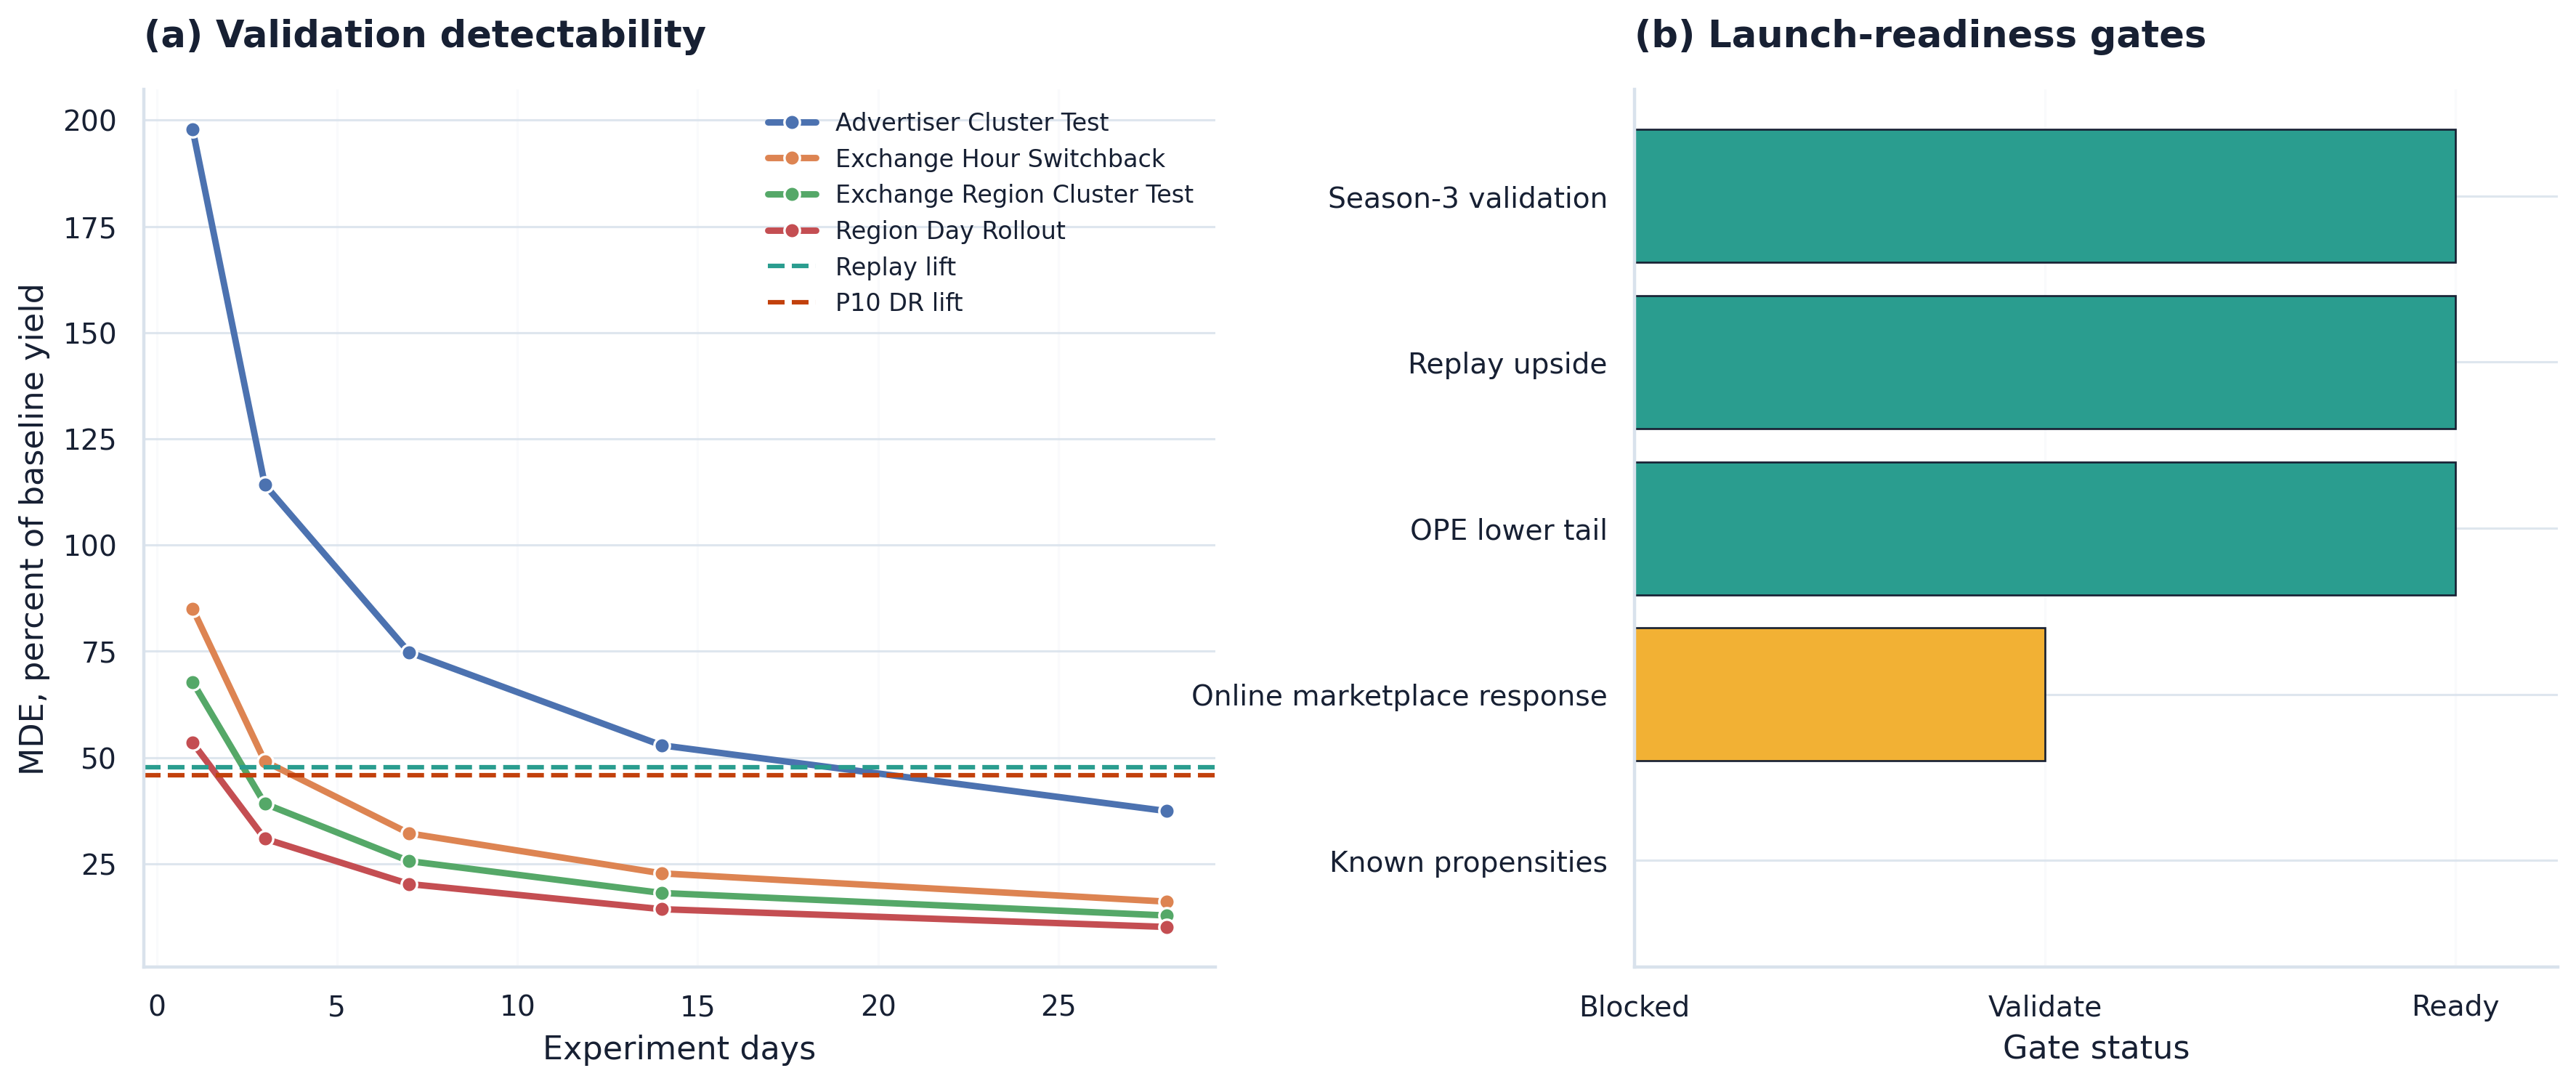

In [8]:
renderer = FigureRenderer(repository, paths.figure_dir, paper_config, progress=progress)

validation_design_path = renderer.plot_validation_design_and_launch_readiness()
print(f"Wrote validation-design and launch-readiness figure to {validation_design_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(validation_design_path)))



## Launch-Readiness Table

The table below records the exact gate statuses shown in panel (b). Replay upside, OPE lower-tail evidence, and Season 3 validation are marked ready. Online marketplace response is validation-ready because it can only be measured under a live controlled design. Known propensities remain blocked until the system logs real assignment probabilities.



In [9]:
checklist.sort_values("status_score", ascending=False)



,gate,status,status_score
0,Replay upside,ready,2
1,OPE lower tail,ready,2
2,Season-3 validation,ready,2
4,Online marketplace response,validation_ready,1
3,Known propensities,blocked,0


In [10]:
# The launch-readiness checklist is displayed as panel (b) of the combined figure above.
# The separate renderer remains available for compatibility with older paper builds.



## Final Recommendation and Validation Sequence

The decision waterfall states the core DSS recommendation. The priority policy has strong offline evidence and survives robustness checks, but direct launch is blocked by missing real propensities and unvalidated marketplace response. The paired validation sequence turns the recommendation into an implementation plan: shadow logging, exchange-hour switchback, daily guardrail review, and ramped launch only after all gates pass.



In [11]:
recommendation[[
    "policy_id",
    "recommended_action",
    "final_decision",
    "direct_launch_ready",
    "why_not_direct_launch",
    "replay_yield_lift",
    "p10_crossfit_dr_lift",
    "break_even_market_response_loss_share",
    "readiness_gates_ready",
    "readiness_gates_validation_ready",
    "readiness_gates_blocked",
    "primary_validation_design",
    "minimum_shadow_logging_duration",
    "minimum_online_test_duration",
]]



,policy_id,recommended_action,final_decision,direct_launch_ready,why_not_direct_launch,replay_yield_lift,p10_crossfit_dr_lift,break_even_market_response_loss_share,readiness_gates_ready,readiness_gates_validation_ready,readiness_gates_blocked,primary_validation_design,minimum_shadow_logging_duration,minimum_online_test_duration
0,hybrid_q75_if_gap_100,"Start shadow logging, then run an exchange-hou...",shadow_log_then_exchange_hour_switchback,False,missing real known propensities and unvalidate...,0.476604,0.458253,0.32277,3,1,1,exchange_hour_switchback,7 to 14 days,14 days


Wrote decision waterfall and validation sequence figure to artifacts/figures/11_decision_waterfall_and_validation_sequence.png


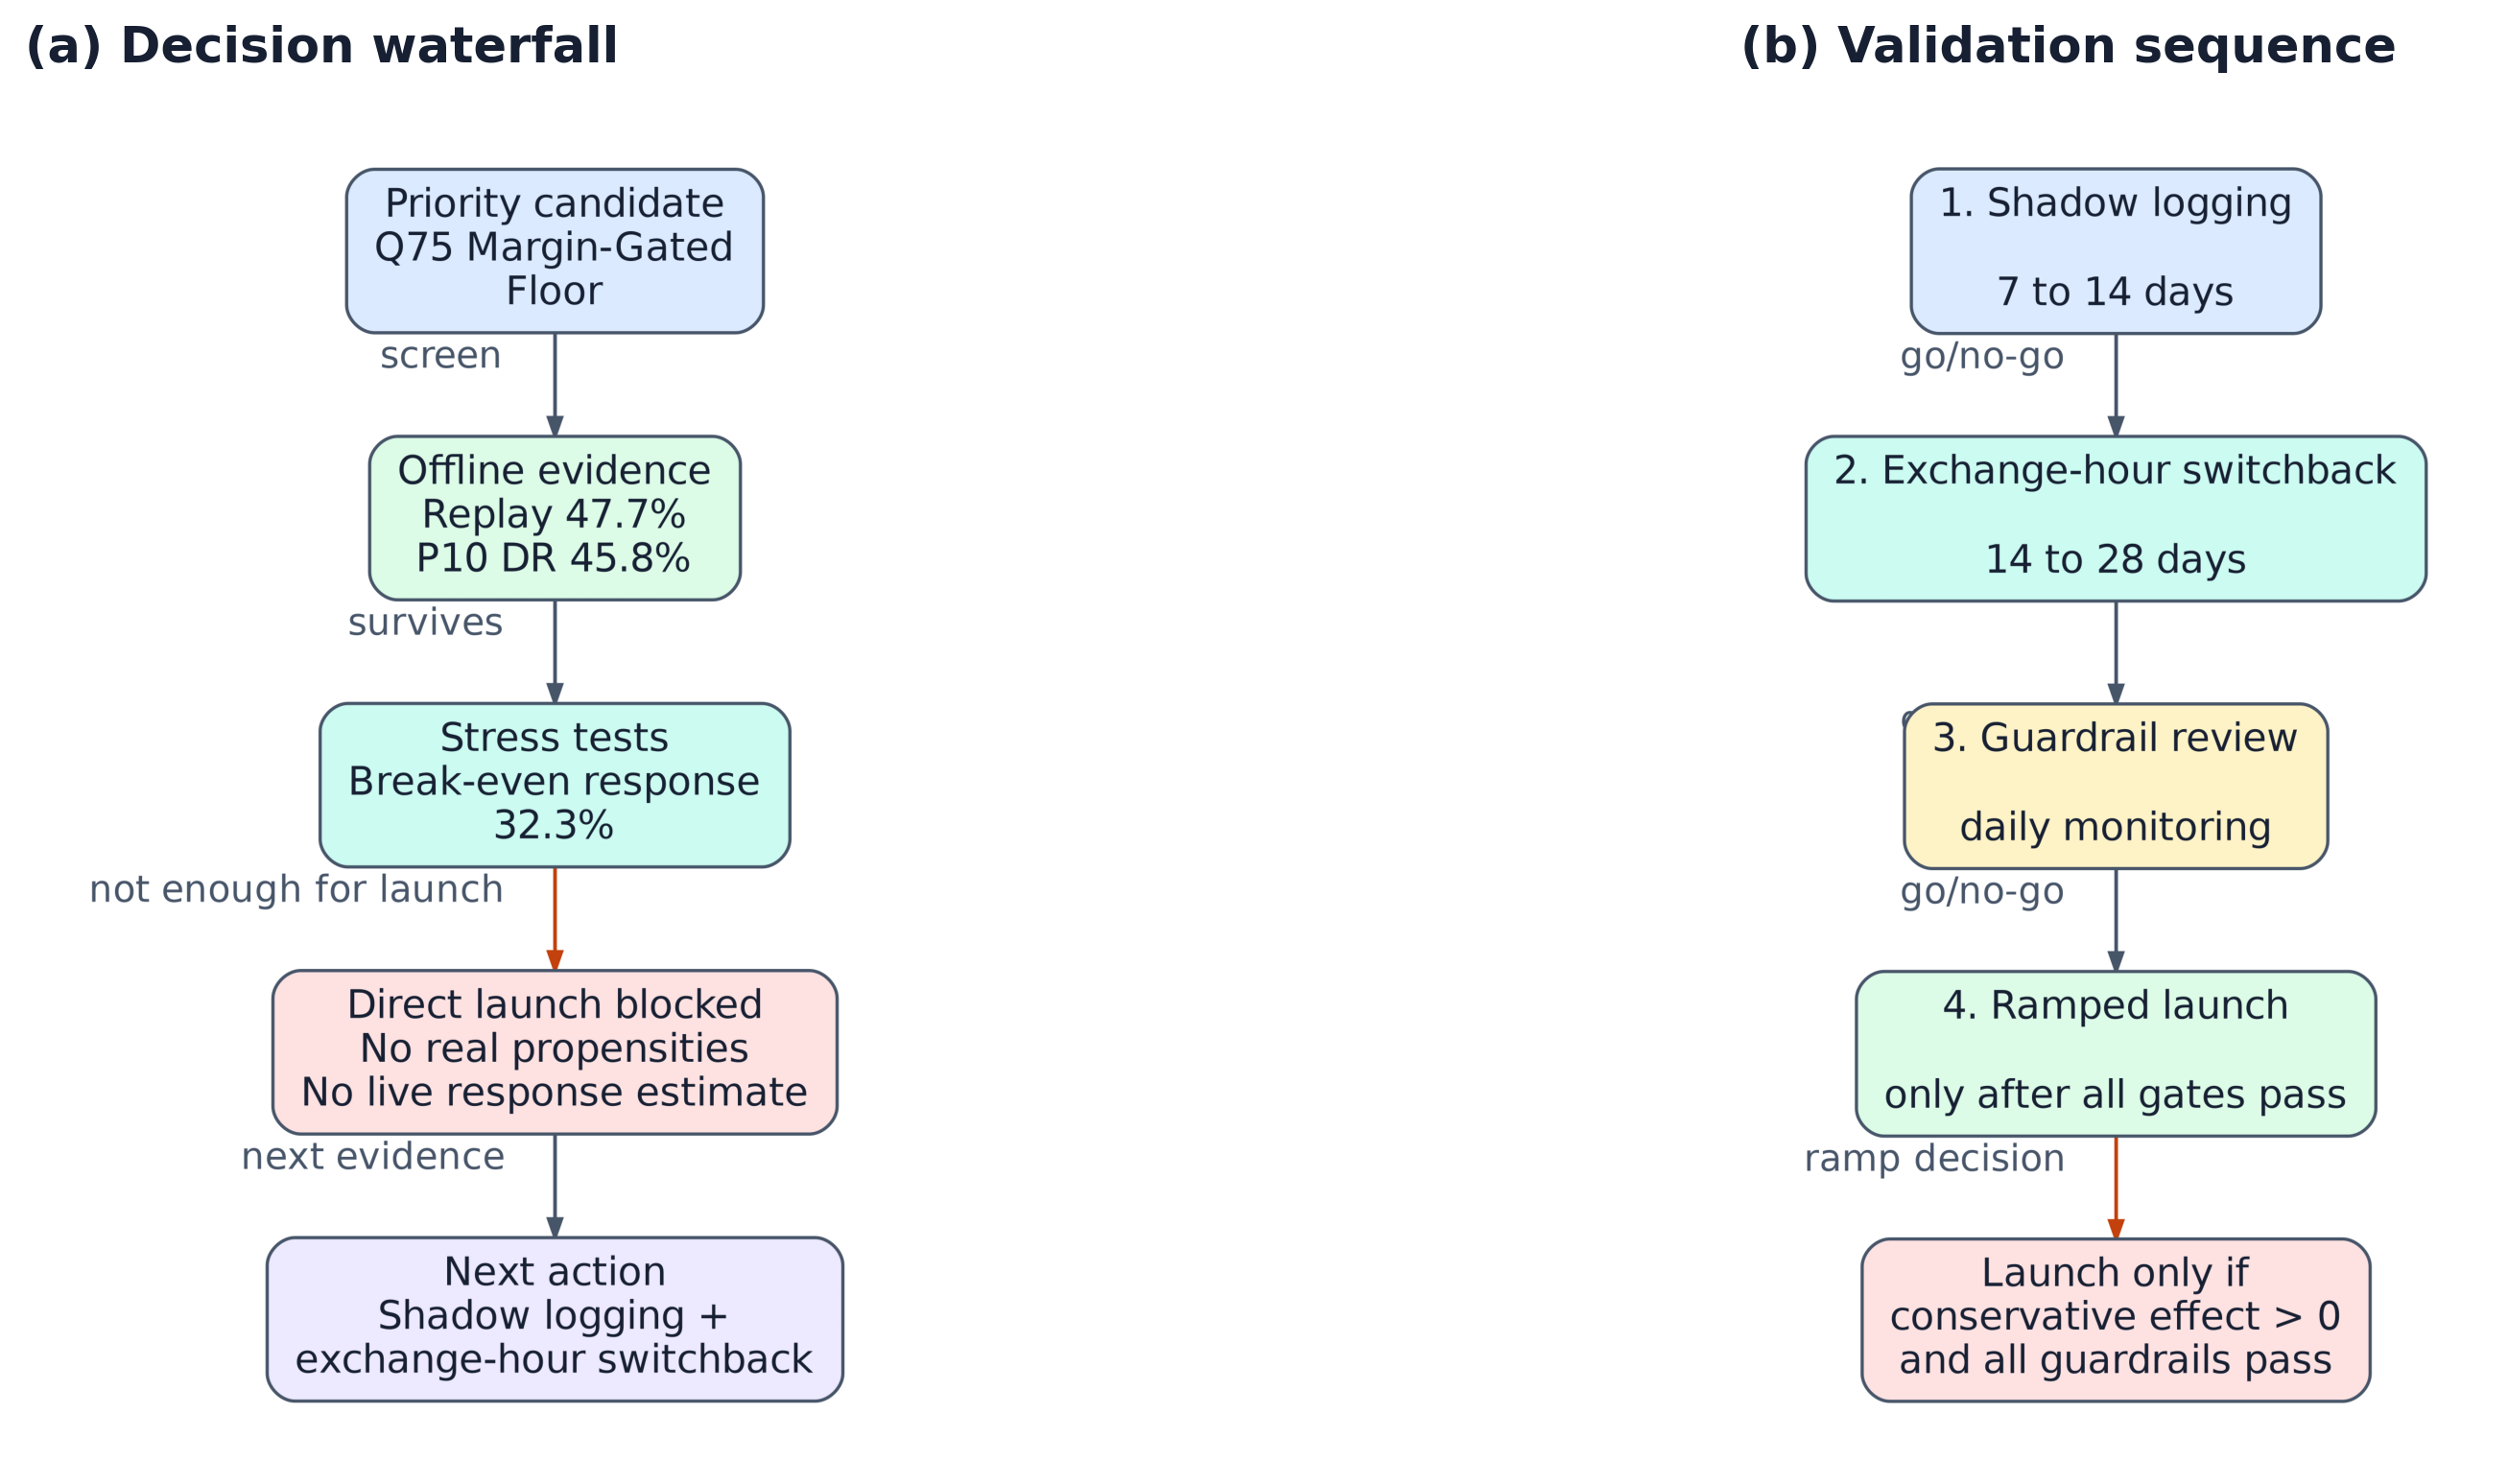

In [12]:
decision_sequence_path = renderer.plot_decision_waterfall_and_validation_sequence()
print(f"Wrote decision waterfall and validation sequence figure to {decision_sequence_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(decision_sequence_path)))



## Validation Sequence Table

The table below records the same implementation sequence shown in panel (b). Each stage creates evidence required by the next stage: shadow logging establishes instrumentation and support; switchback validation estimates live response; daily guardrail review prevents unsafe ramping; and launch is allowed only after all gates pass.



In [13]:
sequence.sort_values("phase_order")



,phase_order,phase,duration
0,1,Shadow logging,7 to 14 days
1,2,Exchange-hour switchback,14 to 28 days
2,3,Guardrail review,daily monitoring
3,4,Ramped launch,only after all gates pass


In [14]:
# The validation sequence is displayed as panel (b) of the combined decision figure above.
# The separate renderer remains available for compatibility with older paper builds.



## Interpretation for the Paper

This notebook is the decision-support endpoint for the empirical workflow. It does not add another offline estimator; it organizes the evidence into a launch decision. The priority policy is not rejected because the replay, OPE, robustness, and Season 3 validation evidence are all favorable. It is not directly launched because the remaining uncertainties are precisely the ones offline data cannot resolve: true assignment propensities, bidder response, pacing response, and marketplace equilibrium behavior. The recommended action is therefore validation, not launch.

